## High Performance Income Prediction

Data source: https://www.kaggle.com/datasets/uciml/adult-census-income

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
data = pd.read_csv('archive/adult.csv')
data

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


### Preprocessing

In [3]:
df = data.copy()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


#### Missing values

In [5]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [6]:
data.isin(['?']).sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [7]:
df['workclass'].unique()

<StringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [8]:
df['occupation'].unique()

<StringArray>
[                '?',   'Exec-managerial', 'Machine-op-inspct',
    'Prof-specialty',     'Other-service',      'Adm-clerical',
      'Craft-repair',  'Transport-moving', 'Handlers-cleaners',
             'Sales',   'Farming-fishing',      'Tech-support',
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

In [9]:
df['native.country'].unique()

<StringArray>
[             'United-States',                          '?',
                     'Mexico',                     'Greece',
                    'Vietnam',                      'China',
                     'Taiwan',                      'India',
                'Philippines',            'Trinadad&Tobago',
                     'Canada',                      'South',
         'Holand-Netherlands',                'Puerto-Rico',
                     'Poland',                       'Iran',
                    'England',                    'Germany',
                      'Italy',                      'Japan',
                       'Hong',                   'Honduras',
                       'Cuba',                    'Ireland',
                   'Cambodia',                       'Peru',
                  'Nicaragua',         'Dominican-Republic',
                      'Haiti',                'El-Salvador',
                    'Hungary',                   'Columbia',
          

In [10]:
df = df.replace('?', np.nan)

In [11]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

#### Encoding

In [12]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [13]:
df.loc[:, ['education', 'education.num']]

,education,education.num
0,HS-grad,9
1,HS-grad,9
2,Some-college,10
3,7th-8th,4
4,Some-college,10
...,...,...
32556,Some-college,10
32557,Assoc-acdm,12
32558,HS-grad,9
32559,HS-grad,9


In [14]:
df = df.drop('education', axis=1)

In [15]:
categorical_features = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

In [16]:
def get_categorical_uniques(df, columns):
    categorical_uniques = dict()
    for column in columns:
        categorical_uniques[column] = list(df[column].unique())
    return categorical_uniques

In [17]:
get_categorical_uniques(df, categorical_features)

{'workclass': [nan,
  'Private',
  'State-gov',
  'Federal-gov',
  'Self-emp-not-inc',
  'Self-emp-inc',
  'Local-gov',
  'Without-pay',
  'Never-worked'],
 'marital.status': ['Widowed',
  'Divorced',
  'Separated',
  'Never-married',
  'Married-civ-spouse',
  'Married-spouse-absent',
  'Married-AF-spouse'],
 'occupation': [nan,
  'Exec-managerial',
  'Machine-op-inspct',
  'Prof-specialty',
  'Other-service',
  'Adm-clerical',
  'Craft-repair',
  'Transport-moving',
  'Handlers-cleaners',
  'Sales',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv',
  'Armed-Forces',
  'Priv-house-serv'],
 'relationship': ['Not-in-family',
  'Unmarried',
  'Own-child',
  'Other-relative',
  'Husband',
  'Wife'],
 'race': ['White',
  'Black',
  'Asian-Pac-Islander',
  'Other',
  'Amer-Indian-Eskimo'],
 'sex': ['Female', 'Male'],
 'native.country': ['United-States',
  nan,
  'Mexico',
  'Greece',
  'Vietnam',
  'China',
  'Taiwan',
  'India',
  'Philippines',
  'Trinadad&Tobago',
  'Canada',
  

In [18]:
binary_features = ['sex']

nominal_features = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'native.country']

In [19]:
def binary_encode(df, columns):
    df = df.copy()
    label_encoder = LabelEncoder()
    for column in columns:
        df[column] = label_encoder.fit_transform(df[column])
    return df

In [20]:
def onehot_encode(df, columns):
    df = df.copy()
    for column in columns:
        dummies = pd.get_dummies(df[column], dtype=int)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

In [21]:
df = binary_encode(df, binary_features)
df = onehot_encode(df, nominal_features)

In [22]:
df

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,income,Federal-gov,Local-gov,...,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,United-States,Vietnam,Yugoslavia
0,90,77053,9,0,0,4356,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
1,82,132870,9,0,0,4356,18,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,186061,10,0,0,4356,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
3,54,140359,4,0,0,3900,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
4,41,264663,10,0,0,3900,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,1,0,0,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
32557,27,257302,12,0,0,0,38,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
32558,40,154374,9,1,0,0,40,>50K,0,0,...,0,0,0,0,0,0,0,1,0,0
32559,58,151910,9,0,0,0,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0


In [23]:
(df.dtypes == 'str').sum()

np.int64(1)

#### Scaling

In [24]:
y = df['income'].copy()
X = df.drop('income', axis=1).copy()

In [25]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [26]:
y

array([0, 0, 0, ..., 1, 0, 0], shape=(32561,))

In [27]:
y_mappings = {index: label for index, label in enumerate(label_encoder.classes_)}
y_mappings

{0: '<=50K', 1: '>50K'}

In [28]:
y

array([0, 0, 0, ..., 1, 0, 0], shape=(32561,))

In [29]:
X.columns

Index(['age', 'fnlwgt', 'education.num', 'sex', 'capital.gain', 'capital.loss',
       'hours.per.week', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private',
       'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay',
       'Divorced', 'Married-AF-spouse', 'Married-civ-spouse',
       'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed',
       'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial',
       'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct',
       'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv',
       'Sales', 'Tech-support', 'Transport-moving', 'Husband', 'Not-in-family',
       'Other-relative', 'Own-child', 'Unmarried', 'Wife',
       'Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White',
       'Cambodia', 'Canada', 'China', 'Columbia', 'Cuba', 'Dominican-Republic',
       'Ecuador', 'El-Salvador', 'England', 'France', 'Germany', 'Greece',
       'Guatemala', 'Haiti', 'Holand-Net

In [30]:
scaler = MinMaxScaler()

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [31]:
X

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,Federal-gov,Local-gov,Never-worked,...,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,United-States,Vietnam,Yugoslavia
0,1.000000,0.043987,0.533333,0.0,0.0,1.000000,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.890411,0.081896,0.533333,0.0,0.0,1.000000,0.173469,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.671233,0.118021,0.600000,0.0,0.0,1.000000,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.506849,0.086982,0.200000,0.0,0.0,0.895317,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.328767,0.171404,0.600000,0.0,0.0,0.895317,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.068493,0.202298,0.600000,1.0,0.0,0.000000,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32557,0.136986,0.166404,0.733333,0.0,0.0,0.000000,0.377551,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32558,0.315068,0.096500,0.533333,1.0,0.0,0.000000,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32559,0.561644,0.094827,0.533333,0.0,0.0,0.000000,0.397959,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Training

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1)

In [36]:
inputs = tf.keras.Input(shape=(88, ))
x = tf.keras.layers.Dense(16, activation='relu')(inputs)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='acc'),
    tf.keras.metrics.AUC(name='auc')
]

model.compile(
    optimizer = optimizer,
    loss = 'binary_crossentropy',
    metrics = metrics
)

batch_size = 32
epochs = 100

history = model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    batch_size = batch_size,
    epochs = epochs
)

Epoch 1/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.8065 - auc: 0.8296 - loss: 0.4122 - val_acc: 0.8134 - val_auc: 0.8711 - val_loss: 0.3780
Epoch 2/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8350 - auc: 0.8810 - loss: 0.3559 - val_acc: 0.8298 - val_auc: 0.8871 - val_loss: 0.3527
Epoch 3/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8422 - auc: 0.8943 - loss: 0.3373 - val_acc: 0.8376 - val_auc: 0.8955 - val_loss: 0.3406
Epoch 4/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8481 - auc: 0.9022 - loss: 0.3255 - val_acc: 0.8384 - val_auc: 0.8984 - val_loss: 0.3349
Epoch 5/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8517 - auc: 0.9055 - loss: 0.3197 - val_acc: 0.8409 - val_auc: 0.9011 - val_loss: 0.3305
Epoch 6/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8541 - auc: 0.9082 - loss: 0.3155 - val_acc: 0.8405 - val_auc: 0.9015 - val_loss: 0.3301
Epoch 7/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8543 - auc: 0.9098 - loss: 0.313

### Results

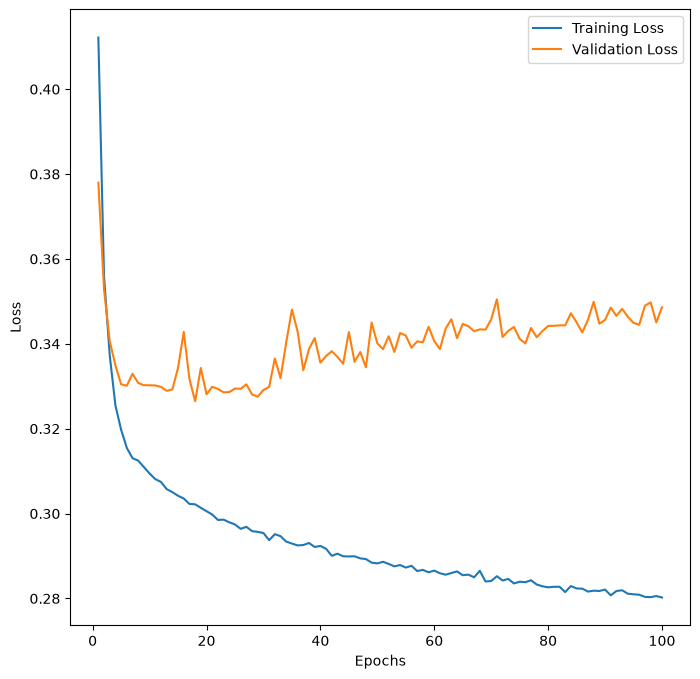

In [38]:
plt.figure(figsize=(8,8))

epochs_range = range(1, epochs + 1)
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [39]:
np.argmin(val_loss)

np.int64(17)

In [40]:
model.evaluate(X_test, y_test)

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8517 - auc: 0.9062 - loss: 0.3284


[0.3284439146518707, 0.8516812324523926, 0.9062261581420898]

In [41]:
y.sum() / len(y)

np.float64(0.2408095574460244)